# Old vs new feature bounding-box extents

How big were the features the first-generation analysis was actually measuring?
This notebook compares feature **bounding-box side lengths**, per model, between the
archived ("old") DYAMOND feature tables and the current pipeline. GPM is excluded on
both sides.

## What the two datasets actually contain

The old and new tables do not share an extent column, so both sides are converted to
km bounding-box side lengths:

| | old | new |
|---|---|---|
| bounding box | `min/max_latitude`, `min/max_longitude` (**lat/lon-aligned**) | `along_swath_extent_km`, `cross_swath_extent_km` (**swath-aligned**) |
| size | `number_pixels` | `size_px` |
| max precip | `max_precip` | `max_precip_mm_hr` |
| completeness | `is_complete` | `edge_frac <= 0.05`, `~touches_domain_edge` |

Note the old data has no `south_lat`/`north_lat`/`east_lon`/`west_lon`, and the new
DYAMOND data has no `lat_extent_deg`/`lon_extent_deg` — those exist only in the new
*GPM* table, which is not used here.

Only `GEOS`, `ICON`, `SCREAM` and `gSAM` have archived tables; MPAS, SHiELD, ARPEGE and
GRIST do not.

## Caveats

1. **Orientation.** The old box is aligned to lat/lon, the new one to the swath axes.
   For an isotropically-oriented feature population the two distributions agree; for an
   individual feature elongated at 45 deg to the swath they do not. This is a floor on
   the precision of the comparison and cannot be removed without recomputing extents
   from the source masks.
2. **No edge-fraction analogue in the old data.** `is_complete` is the only completeness
   flag available; the new side uses `edge_frac <= 0.05`.
3. **gSAM accumulation.** The new side uses `15minaccum` for all four models. The old
   gSAM field was instantaneous.
4. **ICON old field** was a 3-hourly mean, not a 15-min accumulation — an independent
   reason for the ICON panel to differ.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from src.reading import read_archived_dyamond_feature_stats, KM_PER_DEG
from src.samples import load_gpm_dyamond_features
from src.plotting import source_line_params
from src.saving import save_figure, save_table

In [2]:
MODELS = ["GEOS", "ICON", "SCREAM", "gSAM"]  # GPM deliberately excluded

new_features = {
    source: df
    for source, df in load_gpm_dyamond_features().items()
    if source in MODELS
}

# Matched cuts: maxpr >= 10 mm/hr, |lat| <= 20, >= 5 px, complete features only
old_features = {model: read_archived_dyamond_feature_stats(model) for model in MODELS}
old_features_raw = {
    model: read_archived_dyamond_feature_stats(model, deduplicate=False)
    for model in MODELS
}

for model in MODELS:
    n_raw = old_features_raw[model].height
    n_old = old_features[model].height
    n_new = new_features[model].height
    assert n_old > 0 and n_new > 0, f"Empty frame for {model}"
    print(
        f"{model:7s} old {n_raw:9,d} rows -> {n_old:8,d} features "
        f"({n_raw / n_old:5.1f} rows/feature) | new {n_new:8,d} features"
    )

GEOS    old 3,209,151 rows ->  231,818 features ( 13.8 rows/feature) | new  321,979 features
ICON    old 6,424,060 rows ->  209,376 features ( 30.7 rows/feature) | new  628,422 features
SCREAM  old 6,060,191 rows ->  282,422 features ( 21.5 rows/feature) | new  636,968 features
gSAM    old 3,756,354 rows ->  300,419 features ( 12.5 rows/feature) | new  309,108 features


In [3]:
# Both datasets report pixel-centre to pixel-centre spans, so a single-pixel-wide
# feature has an extent of exactly zero. Adding one grid cell makes the small end
# comparable and keeps every value inside the log bins. Exact for the old
# (lat/lon-aligned) side, approximate for the new (swath-aligned) one.
ADD_PIXEL_FOOTPRINT = True
PIXEL_KM = 0.05 * KM_PER_DEG


def axes_km(df, dataset):
    """Return (short axis, long axis) bounding-box side lengths in km."""
    if dataset == "old":
        a = df["lat_extent_km"].to_numpy()
        b = df["lon_extent_km"].to_numpy()
    else:
        a = df["along_swath_extent_km"].to_numpy()
        b = df["cross_swath_extent_km"].to_numpy()
    if ADD_PIXEL_FOOTPRINT:
        a, b = a + PIXEL_KM, b + PIXEL_KM
    return np.minimum(a, b), np.maximum(a, b)


extents = {
    (dataset, model): axes_km(features[model], dataset)
    for dataset, features in (("old", old_features), ("new", new_features))
    for model in MODELS
}

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/OldNew_Extent_Histograms.pdf as PDF ...


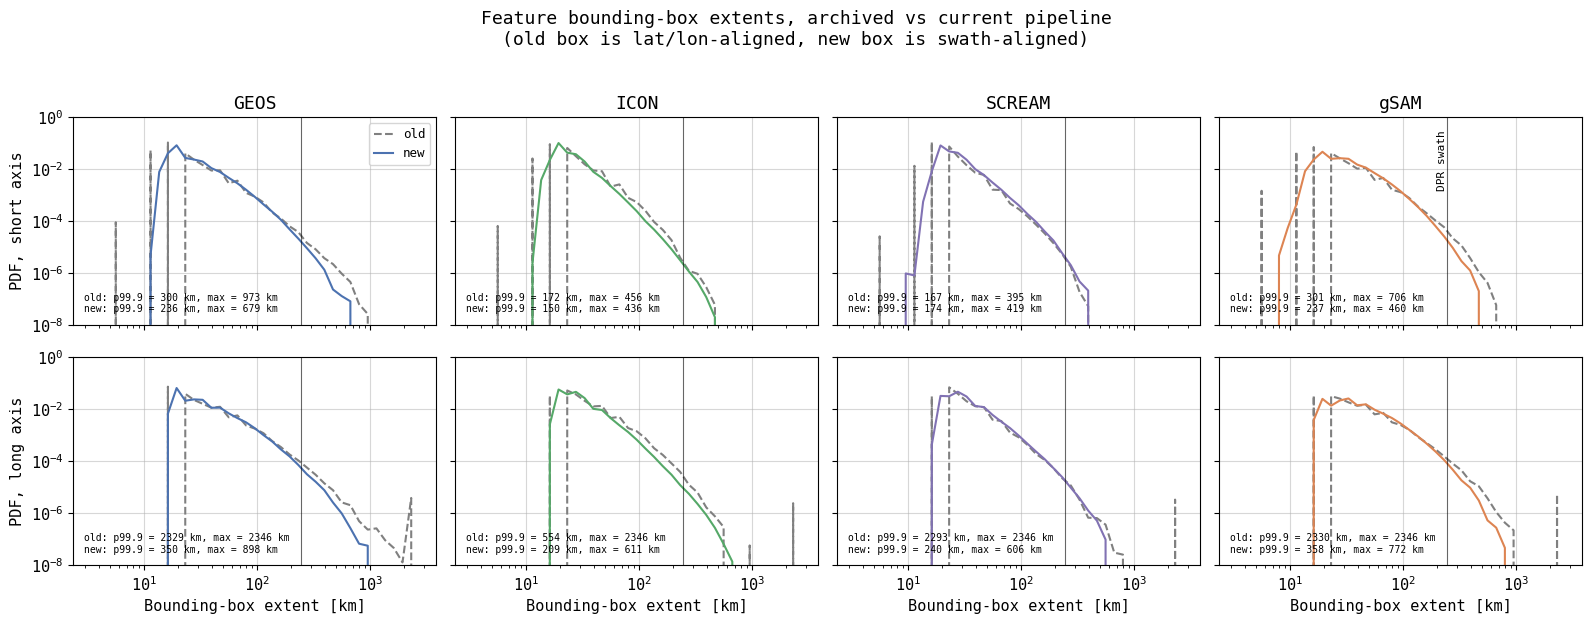

In [4]:
BINS = np.logspace(np.log10(3), np.log10(3000), 40)
BIN_CENTERS = np.sqrt(BINS[:-1] * BINS[1:])
DPR_SWATH_KM = 245.0  # real GPM DPR swath width

fig, axs = plt.subplots(nrows=2, ncols=len(MODELS), figsize=(16, 6), sharex=True, sharey=True)

for col, model in enumerate(MODELS):
    for row, axis_name in enumerate(["short axis", "long axis"]):
        ax = axs[row, col]
        annotations = []
        for dataset, line_kwargs in (
            ("old", dict(color="grey", linestyle="dashed", lw=1.5)),
            ("new", source_line_params(model)),
        ):
            values = extents[(dataset, model)][row]
            pdf, _ = np.histogram(values, bins=BINS, density=True)
            ax.plot(BIN_CENTERS, pdf, label=dataset, **line_kwargs)
            annotations.append(
                f"{dataset}: p99.9 = {np.percentile(values, 99.9):.0f} km, "
                f"max = {values.max():.0f} km"
            )

        ax.axvline(DPR_SWATH_KM, color="black", lw=0.8, alpha=0.6)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim(1e-8, 1e0)
        ax.grid(alpha=0.5)
        ax.text(
            0.03, 0.05, "\n".join(annotations), transform=ax.transAxes,
            fontsize=7, va="bottom", ha="left",
        )
        if row == 0:
            ax.set_title(model)
        else:
            ax.set_xlabel("Bounding-box extent [km]")
        if col == 0:
            ax.set_ylabel(f"PDF, {axis_name}")

axs[0, 0].legend(fontsize=9, loc="upper right")
axs[0, -1].annotate(
    "DPR swath", xy=(DPR_SWATH_KM, 3e-1), fontsize=8, rotation=90,
    ha="right", va="top",
)
fig.suptitle(
    "Feature bounding-box extents, archived vs current pipeline\n"
    "(old box is lat/lon-aligned, new box is swath-aligned)",
    y=1.03, fontsize=13,
)
fig.tight_layout(pad=1.0)
save_figure(fig, "OldNew_Extent_Histograms.pdf")

In [5]:
rows = []
for model in MODELS:
    for dataset in ("old", "new"):
        for axis_index, axis_name in enumerate(["short", "long"]):
            values = extents[(dataset, model)][axis_index]
            rows.append(
                {
                    "model": model,
                    "dataset": dataset,
                    "axis": axis_name,
                    "n": len(values),
                    "median_km": float(np.median(values)),
                    "p99_km": float(np.percentile(values, 99)),
                    "p99p9_km": float(np.percentile(values, 99.9)),
                    "max_km": float(values.max()),
                    "frac_above_dpr_swath": float((values > DPR_SWATH_KM).mean()),
                }
            )

summary = pl.DataFrame(rows)
save_table(summary, "old_new_extents.csv")
with pl.Config(tbl_rows=-1, float_precision=3):
    print(summary)

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/data/tables/old_new_extents.csv as CSV ...
shape: (16, 9)
┌────────┬─────────┬───────┬────────┬───┬─────────┬──────────┬──────────┬──────────────────────┐
│ model  ┆ dataset ┆ axis  ┆ n      ┆ … ┆ p99_km  ┆ p99p9_km ┆ max_km   ┆ frac_above_dpr_swath │
│ ---    ┆ ---     ┆ ---   ┆ ---    ┆   ┆ ---     ┆ ---      ┆ ---      ┆ ---                  │
│ str    ┆ str     ┆ str   ┆ i64    ┆   ┆ f64     ┆ f64      ┆ f64      ┆ f64                  │
╞════════╪═════════╪═══════╪════════╪═══╪═════════╪══════════╪══════════╪══════════════════════╡
│ GEOS   ┆ old     ┆ short ┆ 231818 ┆ … ┆ 138.994 ┆ 300.226  ┆ 972.956  ┆ 0.002                │
│ GEOS   ┆ old     ┆ long  ┆ 231818 ┆ … ┆ 233.479 ┆ 2329.145 ┆ 2346.213 ┆ 0.009                │
│ GEOS   ┆ new     ┆ short ┆ 321979 ┆ … ┆ 129.521 ┆ 236.333  ┆ 679.135  ┆ 0.001                │
│ GEOS   ┆ new     ┆ long  ┆ 321979 ┆ … ┆ 183.956 ┆ 349.512  ┆ 898.372  ┆ 0.004                │
│ 

## Reading the result

The number to look at is `frac_above_dpr_swath` on the long axis, and the `max_km`
annotation in each panel. A real DPR overpass is ~245 km wide, so a feature whose long
bounding-box axis exceeds that could not have been observed whole by GPM. Any old-side
tail extending well past the vertical line is a feature the old pseudo-swath sampling
(~2500 km wide) admitted and the instrument never could — the mechanism behind the
size-distribution gap between the old model curves and the old GPM curve.

The short-axis row is the control: it is far less sensitive to swath width, so old and
new should agree much more closely there. If the short axis disagrees as badly as the
long axis, the discrepancy is not about swath sampling and something else is wrong.